> **Angepasste Version für den Methodenvergleich (Wachter).**
> Diese Kopie verwendet den **gemeinsamen Klassifikator** `resnet18_fire_224.pth`
> (torchvision-ResNet-18, trainiert in `Train_ResNet18_Fire.ipynb`, Normierung mean/std = 0.5),
> den auch alle anderen Methoden erklären. Geändert gegenüber dem Original:
> (1) Modell-Factory → torchvision-ResNet-18, (2) Checkpoint-Pfad,
> (3) Normierungskonstanten 0.485/0.229 → 0.5 (inkl. hartkodierter Stellen).
> Die Datei `resnet18_fire_224.pth` muss neben dem Notebook liegen.
> Methode/Losses/Splits/Metriken sind unverändert.

# Wachter-CFE: Fire Detection (fire vs. no_fire)

Wachter et al. (2017) — *Counterfactual Explanations without Opening the Black Box*.
Pixelraum-Optimierung von δ mit MAD-gewichteter L1-Distanz, ohne Decoder.

Using device: cuda
Base   vorhanden: True
Modell vorhanden: True
train_cfe: {'fire': 7664, 'no_fire': 6458, 'skipped': 0}
Preprocessing fertig ✓
Klassen: ['fire', 'no_fire']
Train: 11298  |  Val(=Test-Pool): 2824
CF pool: 2824  |  MAD pool: 11298
Modell geladen und eingefroren.
Klassen:       ['fire', 'no_fire']
Val Accuracy:  0.6835075493612079
Sampling query image …
Query idx    : 8909
Query label  : 1 (no_fire) | Confidence: 0.9136
CF target    : 0 (fire)
Computing MAD …
MAD computed.

══ Seed 0 ══
  Seed 0 | λ=0.0100 | step 000 | loss=0.0245 | pred=no_fire
  Seed 0 | λ=0.0100 | step 200 | loss=0.0229 | pred=no_fire
  Seed 0 | λ=0.0100 | step 400 | loss=0.0220 | pred=no_fire
  Seed 0 | λ=0.0100 | step 600 | loss=0.0212 | pred=no_fire
  Seed 0 | λ=0.0100 | step 800 | loss=0.0206 | pred=no_fire
  Seed 0 | λ=0.0150 | step 000 | loss=0.0270 | pred=no_fire
  Seed 0 | λ=0.0150 | step 200 | loss=0.0254 | pred=no_fire
  Seed 0 | λ=0.0150 | step 400 | loss=0.0248 | pred=no_fire
  Seed 0 | λ=

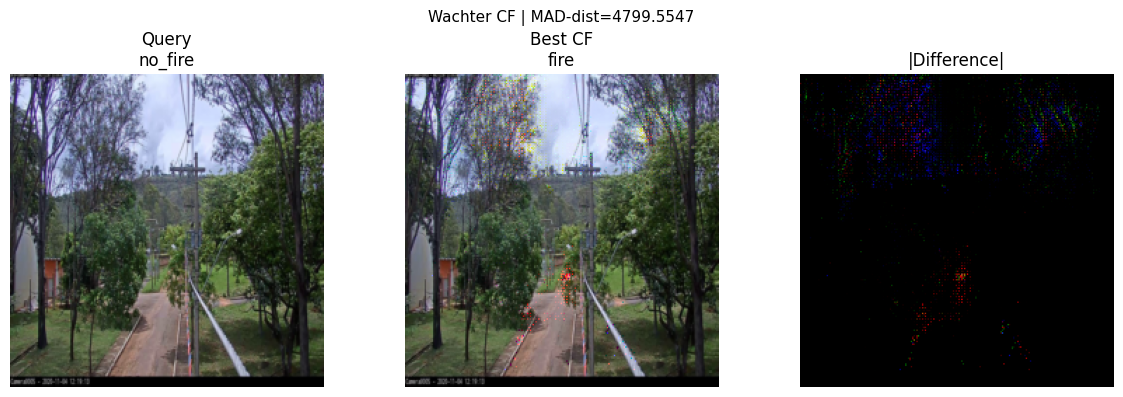

In [1]:
import os
import numpy as np
from glob import glob
from pathlib import Path
from random import randint, sample
from collections import OrderedDict
from functools import partial

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt

torch.manual_seed(2024)
np.random.seed(2024)

# ── Paths (Kaggle mount) ────────────────────────────────────────────────────
BASE_DIR   = '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo'
OUTPUT_DIR = '/kaggle/working/classification_dataset'
PTH_PATH   = 'resnet18_fire_224.pth'   # gemeinsamer Klassifikator

# ── Constants ───────────────────────────────────────────────────────────────
IMG_SIZE      = 224
IMAGENET_MEAN = [0.5, 0.5, 0.5]
IMAGENET_STD  = [0.5, 0.5, 0.5]
# ImageFolder sortiert alphabetisch: fire=0, no_fire=1
CLASS_NAMES   = {0: 'fire', 1: 'no_fire'}
BATCH_SIZE    = 16
NUM_WORKERS   = 2
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
print('Base   vorhanden:', os.path.exists(BASE_DIR))
print('Modell vorhanden:', os.path.exists(PTH_PATH))

# ── 1. Preprocessing — YOLO-Bilder in fire/ und no_fire/ einsortieren ────────
def parse_yolo_label(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            x_c, y_c, w, h = map(float, parts[1:5])
            boxes.append((cls_id, x_c, y_c, w, h))
    return boxes

def process_split(images_dir, labels_dir, output_dir, split_name):
    images_path = Path(images_dir)
    labels_path = Path(labels_dir)
    out_path    = Path(output_dir) / split_name
    for cls_name in ['fire', 'no_fire']:
        (out_path / cls_name).mkdir(parents=True, exist_ok=True)
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    image_files = sorted(f for f in images_path.iterdir()
                         if f.suffix.lower() in image_extensions)
    stats = {'fire': 0, 'no_fire': 0, 'skipped': 0}
    for img_file in image_files:
        label_file = labels_path / (img_file.stem + '.txt')
        boxes      = parse_yolo_label(label_file)
        cls_name   = 'fire' if boxes else 'no_fire'
        try:
            img = Image.open(img_file).convert('RGB')
            img.save(out_path / cls_name / (img_file.stem + '.jpg'), quality=95)
            stats[cls_name] += 1
        except Exception:
            stats['skipped'] += 1
    print(f'{split_name}: {stats}')
    return stats

process_split(
    images_dir = f'{BASE_DIR}/data/train/images',
    labels_dir = f'{BASE_DIR}/data/train/labels',
    output_dir = OUTPUT_DIR,
    split_name = 'train_cfe'
)
print('Preprocessing fertig ✓')

# ── 2. Dataset & Split (identisch zu den anderen Fire-Notebooks: Seed 42, 80/20) ──
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ImageFolderWithFnames(datasets.ImageFolder):
    def __getitem__(self, idx):
        image, label = super().__getitem__(idx)
        fname = os.path.basename(self.samples[idx][0])
        return image, label, fname

full_ds = ImageFolderWithFnames(f'{OUTPUT_DIR}/train_cfe', transform=eval_transforms)
n_val   = int(len(full_ds) * 0.2)
n_train = len(full_ds) - n_val
generator = torch.Generator().manual_seed(42)   # gleicher Seed wie Training & andere Fire-Notebooks!
train_split, val_split = random_split(full_ds, [n_train, n_val], generator=generator)

print(f'Klassen: {full_ds.classes}')   # ['fire', 'no_fire']
print(f'Train: {len(train_split)}  |  Val(=Test-Pool): {len(val_split)}')

# CF-Kandidaten kommen aus dem Val-Split (vom Modell beim Training nicht zur Optimierung gesehen).
# MAD wird über eine Stichprobe des Train-Splits geschätzt.
cf_indices  = list(val_split.indices)
mad_indices = list(train_split.indices)
print(f'CF pool: {len(cf_indices)}  |  MAD pool: {len(mad_indices)}')

# ── 3. ResNet-18 (identische Architektur zum Trainingsnotebook) ─────────────
class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks    = nn.Identity()
        self.shortcut  = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels,  self.out_channels,      conv=self.conv,
                    bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock, n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs, downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_model():
    # Gemeinsamer Klassifikator: torchvision-ResNet-18 (statt Eigenbau-ResNet)
    import torchvision
    return torchvision.models.resnet18(num_classes=2)

# ── 4. Modellgewichte laden & einfrieren ────────────────────────────────────
model = build_model().to(DEVICE)
checkpoint = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
for param in model.parameters():
    param.requires_grad = False
print('Modell geladen und eingefroren.')
print(f'Klassen:       {checkpoint.get("class_names")}')
print(f'Val Accuracy:  {checkpoint.get("val_acc", "N/A")}')

# ── 5. Helper: denormalise für Anzeige ──────────────────────────────────────
def denormalize(tensor):
    t = tensor.clone().cpu()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

def to_display(t):
    """CHW → HWC (RGB) numpy für imshow. Akzeptiert Tensor oder ndarray."""
    if isinstance(t, torch.Tensor):
        t = t.numpy()
    return t[0] if t.shape[0] == 1 else t.transpose(1, 2, 0)

# ── 6. Query-Bild wählen (korrekt klassifiziert, hohe Konfidenz) ────────────
print('Sampling query image …')
while True:
    idx = cf_indices[randint(0, len(cf_indices) - 1)]
    query_image, query_label, _ = full_ds[idx]
    query_image_dev = query_image.clone().to(DEVICE)
    with torch.no_grad():
        output = model(query_image_dev.unsqueeze(0))
        probs  = torch.softmax(output, dim=1)
        pred   = output.argmax().item()
        conf   = probs[0, query_label].item()
    if pred == query_label and conf > 0.9:
        break

query_image = query_image_dev
n_pixels    = query_image.numel()
cf_target   = 1 - query_label          # binär flippen

print(f'Query idx    : {idx}')
print(f'Query label  : {query_label} ({CLASS_NAMES[query_label]}) | Confidence: {conf:.4f}')
print(f'CF target    : {cf_target} ({CLASS_NAMES[cf_target]})')

# ── 7. MAD über 1.000 Train-Bilder berechnen ────────────────────────────────
print('Computing MAD …')
mad_sample_idx = sample(mad_indices, min(1000, len(mad_indices)))
all_pixels     = torch.stack([full_ds[i][0] for i in mad_sample_idx])   # [N, C, H, W]
median         = all_pixels.median(dim=0).values
mad            = (all_pixels - median).abs().median(dim=0).values
mad            = mad.clamp(min=1e-6).to(DEVICE)
print('MAD computed.')

# ── 8. Wachter-Optimierung (Demo an einem Query-Bild) ───────────────────────
# Loss: L(δ) = λ · CE(f(x+δ), y_cf) + (1/n) Σ |δ_i| / MAD_i
error                = nn.CrossEntropyLoss()
learning_rate        = 0.001
lambda_step          = 1.5
confidence_threshold = 0.8

seeds   = [0, 42, 123]
best_cf   = None
best_dist = float('inf')

for seed in seeds:
    torch.manual_seed(seed)
    lambda_val = 0.01
    print(f'\n══ Seed {seed} ══')

    delta        = torch.zeros_like(query_image, requires_grad=True)
    optimizer_cf = torch.optim.Adam([delta], lr=learning_rate)
    for outer in range(10):

        for i in range(1000):
            optimizer_cf.zero_grad()
            cf_image = query_image + delta
            output   = model(cf_image.unsqueeze(0))
            probs    = torch.softmax(output, dim=1)

            dist    = ((cf_image - query_image).abs() / mad).sum() / n_pixels
            cls     = error(output, torch.tensor([cf_target]).to(DEVICE))
            loss_cf = lambda_val * cls + dist

            loss_cf.backward()
            optimizer_cf.step()

            if i % 200 == 0:
                pred_step = output.argmax().item()
                print(f"  Seed {seed} | λ={lambda_val:.4f} | step {i:03d} | "
                      f"loss={loss_cf.item():.4f} | pred={CLASS_NAMES[pred_step]}")

            if probs[0, cf_target].item() >= confidence_threshold:
                print(f'  ✓ Target reached | Seed {seed} | λ={lambda_val:.4f} | step {i}')
                break

        lambda_val *= lambda_step

    current_dist = ((cf_image - query_image).abs() / mad).sum().item()
    if current_dist < best_dist:
        best_dist = current_dist
        best_cf   = cf_image.detach().clone()
        print(f'→ New best CF | Seed {seed} | dist={best_dist:.4f}')

# ── 9. Finales Ergebnis ──────────────────────────────────────────────────────
print(f'\nBest CF | total MAD-distance: {best_dist:.4f}')
with torch.no_grad():
    final_pred = CLASS_NAMES[model(best_cf.unsqueeze(0)).argmax().item()]
print(f'Final prediction on best CF: {final_pred}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cf_np  = denormalize(best_cf.cpu()).numpy()
q_np   = denormalize(query_image.cpu()).numpy()
diff   = np.abs(cf_np - q_np)
diff   = (diff - diff.min()) / (diff.max() + 1e-8)

axes[0].imshow(to_display(q_np)); axes[0].set_title(f'Query\n{CLASS_NAMES[query_label]}')
axes[1].imshow(to_display(cf_np)); axes[1].set_title(f'Best CF\n{final_pred}')
axes[2].imshow(to_display(diff), cmap='hot'); axes[2].set_title('|Difference|')
for ax in axes: ax.axis('off')
plt.suptitle(f'Wachter CF | MAD-dist={best_dist:.4f}', fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/wachter_best_cf_fire.png', dpi=120)
plt.show()


## 10. Bounding Boxes laden (für Lokalisierung / EBPG & BBox-Visualisierung)

In [2]:
import matplotlib.patches as patches
from tqdm import tqdm
import time
from scipy import linalg as scipy_linalg

def load_yolo_bboxes(labels_dir, img_size=224):
    """YOLO-Koordinaten (normalisiert) → absolute Pixel bei img_size. Nur Klasse 0 (fire)."""
    bbox_lookup = {}
    for label_file in Path(labels_dir).glob('*.txt'):
        fname = label_file.stem + '.jpg'   # Preprocessing speichert alles als .jpg
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5 or int(parts[0]) != 0:
                    continue
                x_c, y_c, w, h = map(float, parts[1:5])
                bbox_lookup[fname] = {
                    'x': (x_c - w/2) * img_size,
                    'y': (y_c - h/2) * img_size,
                    'w': w * img_size,
                    'h': h * img_size
                }
                break
    print(f'Fire BBoxen geladen: {len(bbox_lookup)} Bilder')
    return bbox_lookup

bbox_lookup = load_yolo_bboxes(f'{BASE_DIR}/data/train/labels', img_size=IMG_SIZE)

def draw_bbox_on_ax(ax, bbox_dict, image_name, color='red', linewidth=2):
    if image_name not in bbox_dict:
        return False
    b = bbox_dict[image_name]
    rect = patches.Rectangle(
        (b['x'], b['y']), b['w'], b['h'],
        linewidth=linewidth, edgecolor=color,
        facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.text(b['x'], b['y'] - 4, 'GT BBox',
            color=color, fontsize=7, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, pad=1))
    return True


Fire BBoxen geladen: 6894 Bilder


## 11. Wachter als Batch-Funktion (für Flip Rate, Metriken & Coverage)

Pro Bild wird über mehrere Seeds optimiert und das CF mit kleinster MAD-gewichteter
Distanz behalten. Wachter hat keinen Decoder — das CFE-Bild ist direkt x + δ.

In [3]:
def compute_wachter_batch(model, images, device, mad,
                          lambda_init=0.01, lambda_step=1.5, lambda_outer=10,
                          lr=0.001, max_iter=1000, confidence_threshold=0.8,
                          seeds=(0, 42, 123), verbose=False):
    """
    Wachter-CF für einen ganzen Batch.

    Returns
    -------
    xcf_batch     : (B, C, H, W)  beste CFs (normalisiert, wie Modell-Input)
    cfe_labels    : (B,)          Zielklassen (geflippt)
    source_labels : (B,)          ursprüngliche Vorhersagen
    orig_probs    : (B,)          Konfidenz der ursprünglichen Vorhersage
    """
    model.eval()
    images = images.to(device)
    B = images.size(0)
    n_pixels = images[0].numel()
    error = nn.CrossEntropyLoss()

    with torch.no_grad():
        base_logits   = model(images)
        base_probs    = torch.softmax(base_logits, dim=1)
        source_labels = base_logits.argmax(dim=1)
        orig_probs    = base_probs.gather(1, source_labels.unsqueeze(1)).squeeze(1)
    cfe_labels = 1 - source_labels  # binär flippen

    xcf_batch = images.clone()
    best_dist = torch.full((B,), float('inf'), device=device)

    for b in range(B):
        x      = images[b]
        target = int(cfe_labels[b].item())

        for seed in seeds:
            torch.manual_seed(seed)
            lambda_val = lambda_init
            delta = torch.zeros_like(x, requires_grad=True)
            opt   = torch.optim.Adam([delta], lr=lr)
            for _ in range(lambda_outer):

                for _ in range(max_iter):
                    opt.zero_grad()
                    cf_image = x + delta
                    output   = model(cf_image.unsqueeze(0))
                    probs    = torch.softmax(output, dim=1)

                    dist = ((cf_image - x).abs() / mad).sum() / n_pixels
                    cls  = error(output, torch.tensor([target], device=device))
                    loss = lambda_val * cls + dist
                    loss.backward()
                    opt.step()

                    if probs[0, target].item() >= confidence_threshold:
                        break
                lambda_val *= lambda_step

            cf_final = (x + delta).detach()
            cur_dist = ((cf_final - x).abs() / mad).sum()
            if cur_dist < best_dist[b]:
                best_dist[b] = cur_dist
                xcf_batch[b] = cf_final

        if verbose:
            print(f'  Bild {b+1}/{B} | dist={best_dist[b].item():.4f}')

    return xcf_batch.detach(), cfe_labels.cpu(), source_labels.cpu(), orig_probs.cpu()


def get_cfe_image_from_wachter(images, xcf_batch):
    """
    Wachter hat keinen Decoder — das CFE-Bild ist direkt das denormalisierte x+δ.
    Liefert (orig_np, cfe_np) im Format (B, H, W, 3) in [0,1], passend für alle Metriken.
    """
    orig = torch.stack([denormalize(images[i].cpu()) for i in range(images.size(0))])
    cfe  = torch.stack([denormalize(xcf_batch[i].cpu()) for i in range(xcf_batch.size(0))])
    orig_np = orig.permute(0, 2, 3, 1).numpy()
    cfe_np  = cfe.permute(0, 2, 3, 1).numpy()
    return orig_np, cfe_np

print('Wachter-Batch-Funktion definiert ✓')


Wachter-Batch-Funktion definiert ✓


## 12. DataLoader mit Dateinamen (für BBox-Zuordnung)

Der Test-Pool ist der Val-Split (Seed 42, identisch zu den anderen Fire-Notebooks).
`full_ds` nutzt bereits `eval_transforms` (keine Augmentierung).

In [4]:
EVAL_BATCH_SIZE = 8
test_dataset = Subset(full_ds, cf_indices)
test_loader  = DataLoader(test_dataset, batch_size=EVAL_BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
print(f'Test-Loader (mit Dateinamen): {len(test_dataset)} Bilder, '
      f'Batch-Größe {EVAL_BATCH_SIZE}')


Test-Loader (mit Dateinamen): 2824 Bilder, Batch-Größe 8


## 13. Sanity Check — Flip Rate (ein Batch)

In [5]:
sample_images, sample_labels, sample_fnames = next(iter(test_loader))

xcf_batch, cfe_labels, source_labels, orig_probs = compute_wachter_batch(
    model, sample_images, DEVICE, mad,
    lambda_init=0.01, lambda_step=1.5, lambda_outer=10,
    lr=0.001, max_iter=1000, confidence_threshold=0.8,
    seeds=(0, 42, 123)
)

with torch.no_grad():
    cf_logits = model(xcf_batch.to(DEVICE))
    cf_preds  = cf_logits.argmax(dim=1).cpu()

flip_rate = (cf_preds == cfe_labels).float().mean()

print(f'Batch-Größe   : {len(sample_labels)}')
print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >80%)')
print(f'Quellvorhers. : {source_labels.tolist()}')
print(f'CFE-Vorhers.  : {cf_preds.tolist()}')
print(f'Zielklassen   : {cfe_labels.tolist()}')
bbox_count = sum(1 for f in sample_fnames if f in bbox_lookup)
print(f'Bilder mit BBox: {bbox_count}/{len(sample_fnames)}')
if flip_rate < 0.8:
    print('\n⚠ Flip Rate niedrig — max_iter, lambda_outer oder confidence_threshold anpassen')


Batch-Größe   : 8
Flip Rate     : 100.00%  (Ziel: >80%)
Quellvorhers. : [1, 1, 1, 1, 0, 0, 0, 1]
CFE-Vorhers.  : [0, 0, 0, 0, 1, 1, 1, 0]
Zielklassen   : [0, 0, 0, 0, 1, 1, 1, 0]
Bilder mit BBox: 3/8


## 14. Visualisierung mit Bounding Boxes (fire)

Drei-Panel-Darstellung pro Sample: Original+BBox | CFE x+δ | Differenz.

Fire-Bilder mit BBox im Test-Pool: 1396


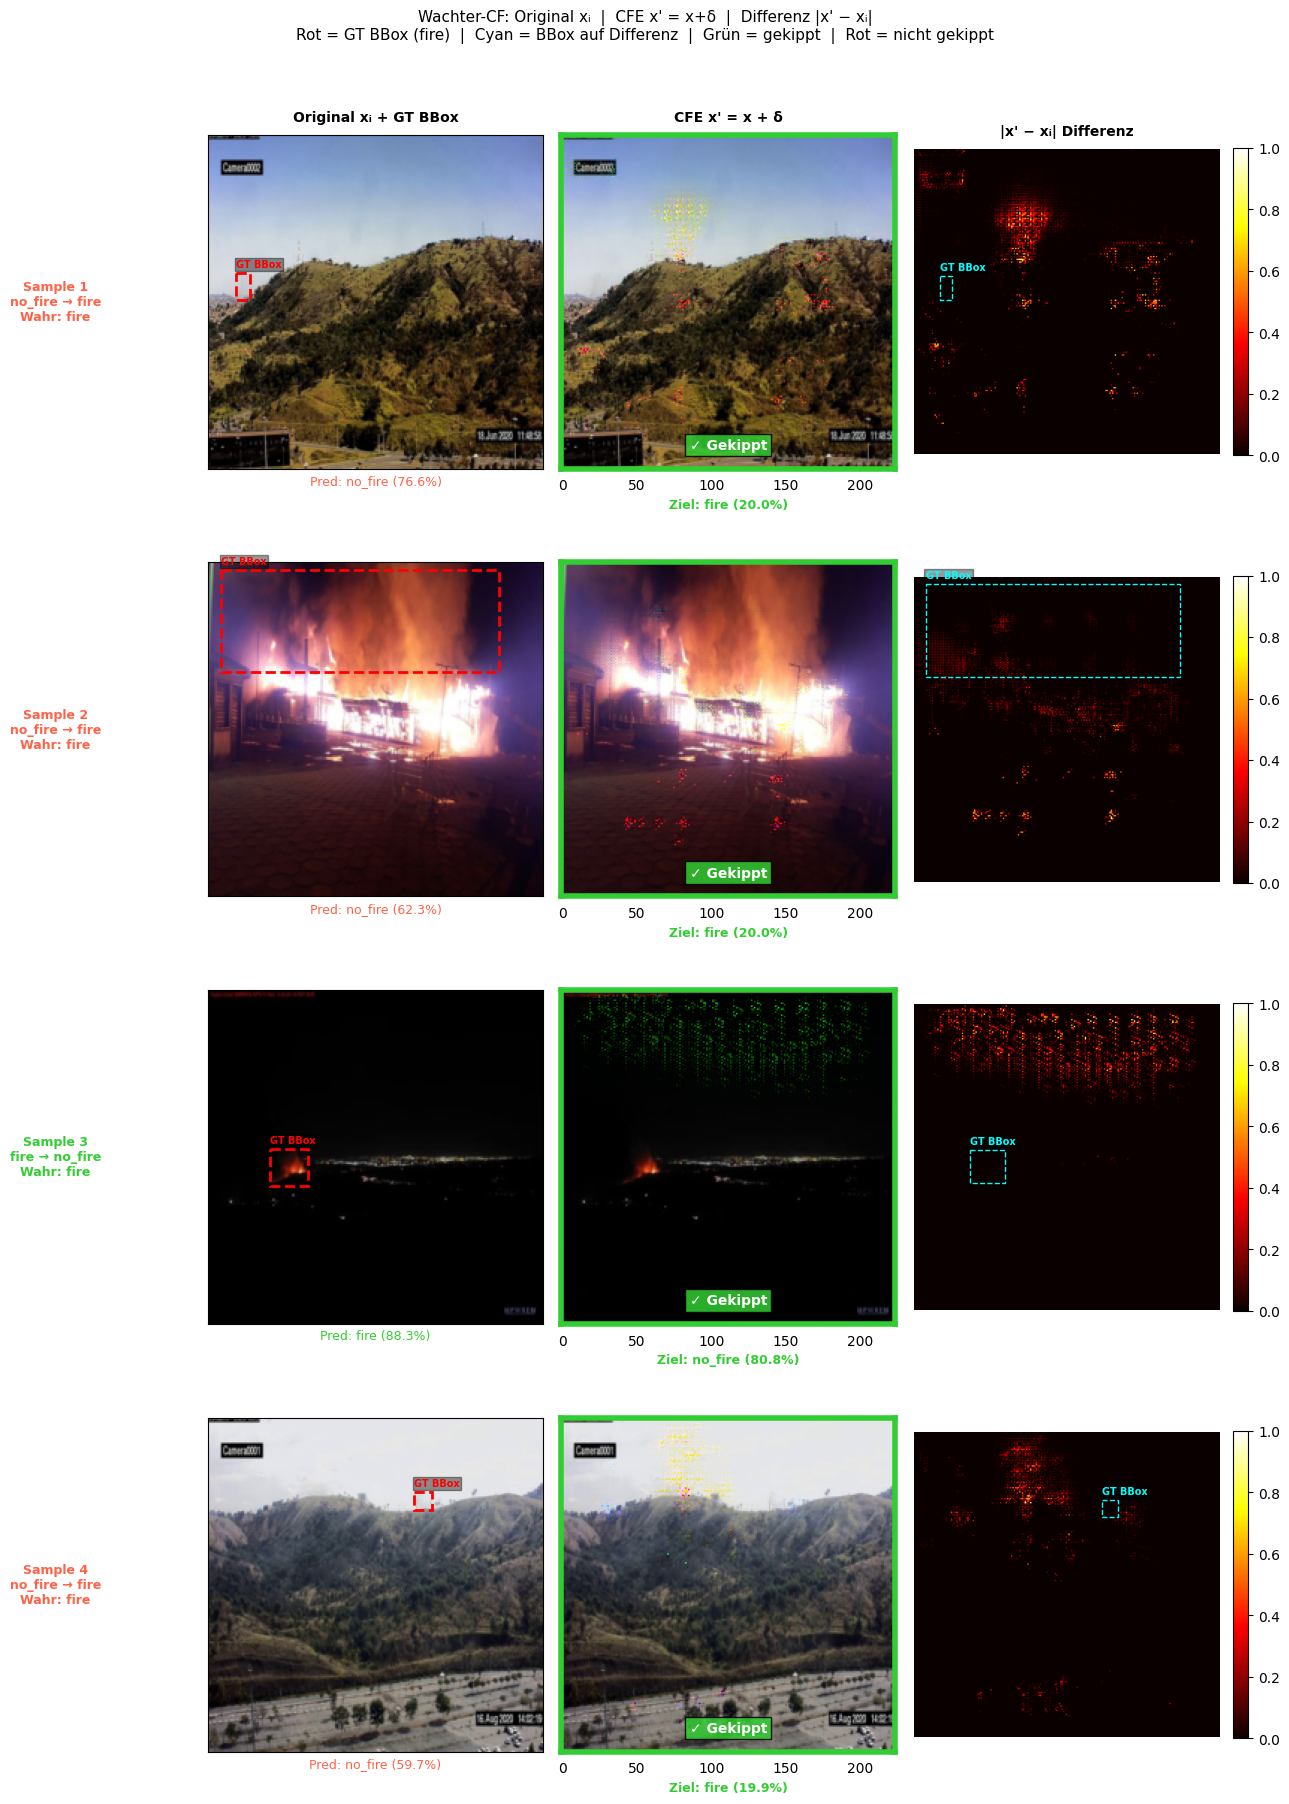

Gespeichert → /kaggle/working/wachter_cf_bbox_fire.png


In [6]:
def visualise_wachter(
    model, images, labels, fnames,
    xcf_batch, cfe_labels, source_labels, orig_probs,
    bbox_lookup, class_names,
    bbox_class_idx=0, bbox_color='red',
    n_samples=4, save_path='/kaggle/working/wachter_cf_bbox_fire.png'
):
    """Drei-Panel-Visualisierung pro Sample (Original+BBox | CFE | Differenz)."""
    model.eval()
    images    = images.to(DEVICE)
    xcf_batch = xcf_batch.to(DEVICE)
    n         = min(n_samples, images.size(0))

    orig_np, cfe_np = get_cfe_image_from_wachter(images[:n], xcf_batch[:n])

    with torch.no_grad():
        cf_logits     = model(xcf_batch[:n])
        cfe_probs_val = torch.softmax(cf_logits, dim=1)[:, 1].cpu().numpy()

    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(13, n * 4.5))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Original xᵢ + GT BBox', "CFE x' = x + δ", "|x' − xᵢ| Differenz"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

    for i in range(n):
        o_np    = orig_np[i]
        c_np    = cfe_np[i]
        diff_np = np.abs(c_np - o_np).mean(axis=2)
        diff_np = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)

        src_lbl  = source_labels[i].item()
        cfe_lbl  = cfe_labels[i].item()
        true_lbl = int(labels[i])
        fname    = fnames[i]
        flipped  = int(cfe_probs_val[i] >= 0.5) == cfe_lbl
        has_bbox = fname in bbox_lookup

        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'

        # Panel 1: Original + BBox
        ax1 = axes[i, 0]
        ax1.imshow(o_np)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax1, bbox_lookup, fname, color=bbox_color)
        elif true_lbl == bbox_class_idx:
            ax1.text(5, IMG_SIZE - 8, 'Keine BBox verfügbar',
                     color='orange', fontsize=6,
                     bbox=dict(facecolor='black', alpha=0.5, pad=1))
        ax1.set_ylabel(
            f'Sample {i+1}\n{class_names[src_lbl]} → {class_names[cfe_lbl]}\n'
            f'Wahr: {class_names[true_lbl]}',
            fontsize=9, color=pred_col, rotation=0,
            labelpad=110, va='center', fontweight='bold')
        ax1.set_xlabel(f'Pred: {class_names[src_lbl]} ({orig_probs_np[i]:.1%})',
                       fontsize=9, color=pred_col)
        ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        # Panel 2: CFE-Bild
        ax2 = axes[i, 1]
        ax2.imshow(c_np)
        for spine in ax2.spines.values():
            spine.set_edgecolor(flip_col)
            spine.set_linewidth(4)
        ax2.text(0.5, 0.05, flip_txt, transform=ax2.transAxes,
                 ha='center', va='bottom', fontsize=10, fontweight='bold',
                 color='white', bbox=dict(facecolor=flip_col, alpha=0.85, pad=3))
        ax2.set_xlabel(f'Ziel: {class_names[cfe_lbl]} ({cfe_probs_val[i]:.1%})',
                       fontsize=9, color=flip_col, fontweight='bold')
        ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=True)

        # Panel 3: Differenzbild
        ax3 = axes[i, 2]
        im  = ax3.imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax3, bbox_lookup, fname, color='cyan', linewidth=1)
        ax3.axis('off')

    plt.suptitle(
        "Wachter-CF: Original xᵢ  |  CFE x' = x+δ  |  Differenz |x' − xᵢ|\n"
        "Rot = GT BBox (fire)  |  Cyan = BBox auf Differenz  |  "
        "Grün = gekippt  |  Rot = nicht gekippt",
        fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert → {save_path}')

# fire-Bilder mit BBox aus dem Test-Pool (val_split)
bbox_fnames_set = set(bbox_lookup.keys())
fire_bbox_indices = [
    i for i in cf_indices
    if full_ds.samples[i][1] == 0   # label 0 = fire
    and os.path.basename(full_ds.samples[i][0]) in bbox_fnames_set
]
print(f'Fire-Bilder mit BBox im Test-Pool: {len(fire_bbox_indices)}')

bbox_subset = Subset(full_ds, fire_bbox_indices)
bbox_loader = DataLoader(bbox_subset, batch_size=4, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=False)
bbox_imgs, bbox_lbls, bbox_fnames = next(iter(bbox_loader))

xcf_b, cfe_b, src_b, prob_b = compute_wachter_batch(
    model, bbox_imgs, DEVICE, mad,
    lambda_init=0.01, lambda_step=1.5, lambda_outer=10,
    lr=0.001, max_iter=1000, confidence_threshold=0.8, seeds=(0, 42, 123)
)

visualise_wachter(
    model=model, images=bbox_imgs, labels=bbox_lbls, fnames=list(bbox_fnames),
    xcf_batch=xcf_b, cfe_labels=cfe_b, source_labels=src_b, orig_probs=prob_b,
    bbox_lookup=bbox_lookup, class_names=CLASS_NAMES,
    bbox_class_idx=0, bbox_color='red', n_samples=4,
    save_path='/kaggle/working/wachter_cf_bbox_fire.png'
)


## 15. Batch-Evaluation — Flip Rate über mehrere Batches

In [7]:
n_batches    = 5
total_flip   = 0
total_images = 0

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        list(test_loader)[:n_batches], desc='Wachter Evaluation'):
    xcf, c_lbls, s_lbls, o_probs = compute_wachter_batch(
        model, batch_imgs, DEVICE, mad,
        lambda_init=0.01, lambda_step=1.5, lambda_outer=10,
        lr=0.001, max_iter=1000, confidence_threshold=0.8, seeds=(0, 42, 123)
    )
    with torch.no_grad():
        preds = model(xcf.to(DEVICE)).argmax(dim=1).cpu()
    total_flip   += (preds == c_lbls).sum().item()
    total_images += len(batch_lbls)

print(f'\nFlip Rate: {total_flip}/{total_images} = {total_flip/total_images:.2%}')


Wachter Evaluation: 100%|██████████| 5/5 [1:11:09<00:00, 853.94s/it]


Flip Rate: 40/40 = 100.00%


## 16. Metriken installieren & definieren

Identische Metrik-Definitionen wie in allen anderen Methodennotebooks.

In [8]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 77.5 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.

In [9]:
# ── LPIPS ─────────────────────────────────────────────────────────────────────
try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE)
    lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen ✓')
except ImportError:
    LPIPS_AVAILABLE = False
    print('⚠ lpips nicht verfügbar — pip install lpips')


# ── 1. L1-Distanz (Proximity) ─────────────────────────────────────────────────
def compute_l1(orig_np, cfe_np):
    diffs = np.abs(orig_np - cfe_np)
    l1 = diffs.sum(axis=(1, 2, 3)) / (orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3])
    return float(l1.mean())


# ── 2. Sparsity Rate (Interpretierbarkeit) ────────────────────────────────────
def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)
    changed = (diff > threshold).astype(float)
    return float(changed.mean(axis=(1, 2)).mean())


# ── 3. LPIPS (Perceptual Similarity) ──────────────────────────────────────────
def compute_lpips(orig_np, cfe_np):
    if not LPIPS_AVAILABLE:
        return None
    orig_t = torch.tensor(orig_np, dtype=torch.float32).permute(0, 3, 1, 2).to(DEVICE) * 2 - 1
    cfe_t  = torch.tensor(cfe_np,  dtype=torch.float32).permute(0, 3, 1, 2).to(DEVICE) * 2 - 1
    with torch.no_grad():
        scores = lpips_fn(orig_t, cfe_t)
    return float(scores.mean().cpu())


# ── 4. FID (Plausibilität) ─────────────────────────────────────────────────────
from torchvision.models import inception_v3

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    if not hasattr(extract_inception_features, '_model'):
        m = inception_v3(weights='DEFAULT', transform_input=False)
        m.fc = nn.Identity()
        extract_inception_features._model = m.eval().to(DEVICE)
    inc, feats = extract_inception_features._model, []
    for i in range(0, len(imgs_np), batch_size):
        t = torch.tensor(imgs_np[i:i+batch_size], dtype=torch.float32).permute(0, 3, 1, 2).to(DEVICE)
        t = torch.nn.functional.interpolate(t, size=(299, 299), mode='bilinear', align_corners=False)
        feats.append(inc(t).cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(real_np, fake_np):
    real_feats = extract_inception_features(real_np)
    fake_feats = extract_inception_features(fake_np)
    mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
    sig_r, sig_f = np.cov(real_feats, rowvar=False), np.cov(fake_feats, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))


# ── 5. EBPG (Lokalisierung, nur BBox-Bilder) ──────────────────────────────────
def compute_ebpg(orig_np, cfe_np, bboxes_pixel):
    scores = []
    for i, bbox in enumerate(bboxes_pixel):
        diff = np.abs(cfe_np[i] - orig_np[i]).mean(axis=-1)
        total = diff.sum() + 1e-8
        x1, y1 = max(0, int(bbox['x'])), max(0, int(bbox['y']))
        x2 = min(IMG_SIZE, int(bbox['x'] + bbox['w']))
        y2 = min(IMG_SIZE, int(bbox['y'] + bbox['h']))
        scores.append(diff[y1:y2, x1:x2].sum() / total)
    return float(np.mean(scores)) if scores else None


# ── 6. Validity & Denoised Validity (Funktionalität) ──────────────────────────
def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    from torchvision.transforms.functional import gaussian_blur
    model.eval()
    cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)
    if denoise_sigma is not None:
        k = max(int(denoise_sigma * 6) | 1, 3)
        cfe_imgs_tensor = gaussian_blur(cfe_imgs_tensor, kernel_size=[k, k],
                                        sigma=[denoise_sigma, denoise_sigma])
    mean = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1, 3, 1, 1)
    std  = torch.tensor(IMAGENET_STD,  device=DEVICE).view(1, 3, 1, 1)
    cfe_norm = (cfe_imgs_tensor - mean) / std
    with torch.no_grad():
        preds = model(cfe_norm).argmax(dim=1).cpu()
    return float((preds == cfe_labels.cpu()).float().mean())


# ── 7. Coverage (Funktionalität) ──────────────────────────────────────────────
def compute_coverage(model, images, mad, n_runs=5):
    """Wie oft findet Wachter über verschiedene Seeds ein valides CF?"""
    rates = []
    for run in range(n_runs):
        xcf, c_lbls, _, _ = compute_wachter_batch(
            model, images, DEVICE, mad,
            lambda_init=0.01, lambda_step=1.5, lambda_outer=10,
            lr=0.001, max_iter=1000, confidence_threshold=0.8,
            seeds=(run,)  # ein Seed pro Run
        )
        with torch.no_grad():
            preds = model(xcf.to(DEVICE)).argmax(dim=1).cpu()
        rates.append((preds == c_lbls).float().mean().item())
    return float(np.mean(rates)), float(np.std(rates))

print('Metrik-Funktionen definiert ✓')

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 63.3MB/s]

Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen ✓
Metrik-Funktionen definiert ✓


## 17. Fester Eval-Satz — einheitlich über alle Methoden

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# FESTER EVAL-SATZ — einheitlich über ALLE Methoden (Seed + BBox-Garantie)
# ══════════════════════════════════════════════════════════════════════════════
# Garantiert, dass jede CF-Methode auf EXAKT denselben 80 Bildern evaluiert und
# EBPG nie leer ist. Die Hälfte sind (sofern verfügbar) BBox-Bilder der Zielklasse.
# Auswahl & Reihenfolge sind über EVAL_SEED reproduzierbar. Der Eval-Satz wird aus
# val_split.indices gezogen (gleicher 80/20-Split, gleicher Generator-Seed 42).

EVAL_SEED     = 42
N_EVAL_IMAGES = 80
TARGET_CLASS  = 0   # Fire: fire-Klasse (hat BBoxen)

_val_idx  = list(val_split.indices)
_idx_bbox = [i for i in _val_idx
             if full_ds.samples[i][1] == TARGET_CLASS
             and os.path.basename(full_ds.samples[i][0]) in bbox_lookup]
_idx_rest = [i for i in _val_idx if i not in set(_idx_bbox)]

_rng = np.random.RandomState(EVAL_SEED)
_rng.shuffle(_idx_bbox)
_rng.shuffle(_idx_rest)

_n_bbox = min(len(_idx_bbox), N_EVAL_IMAGES // 2)
_sel    = _idx_bbox[:_n_bbox] + _idx_rest[:(N_EVAL_IMAGES - _n_bbox)]
_rng2   = np.random.RandomState(EVAL_SEED)
_rng2.shuffle(_sel)
eval_indices = _sel[:N_EVAL_IMAGES]

eval_dataset = Subset(full_ds, eval_indices)
eval_loader  = DataLoader(eval_dataset, batch_size=EVAL_BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

_n_tgt = sum(1 for i in eval_indices if full_ds.samples[i][1] == TARGET_CLASS)
_n_bbx = sum(1 for i in eval_indices
             if os.path.basename(full_ds.samples[i][0]) in bbox_lookup
             and full_ds.samples[i][1] == TARGET_CLASS)
print(f'Fester Eval-Satz: {len(eval_indices)} Bilder (Seed {EVAL_SEED})')
print(f'  Zielklasse:        {_n_tgt}')
print(f'  davon mit BBox:    {_n_bbx}  → EBPG-Stichprobe')


Fester Eval-Satz: 80 Bilder (Seed 42)
  Zielklasse:        45
  davon mit BBox:    40  → EBPG-Stichprobe


## 18. Metriken berechnen — Wachter-CFE Fire Detection

In [11]:
DENOISE_SIGMA  = 1.0

all_l1, all_sparsity, all_lpips = [], [], []
all_real_np, all_cfe_np = [], []
all_eval_imgs = []          # für Coverage über vollen Eval-Satz
all_cfe_tensor, all_cfe_labels = [], []
all_ebpg = []
total_time, n_images = 0.0, 0

print(f'Berechne Metriken über {len(eval_dataset)} Bilder (fester Eval-Satz)...')
print('-' * 60)

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        eval_loader, desc='Metrik-Evaluation'):

    t0 = time.time()
    xcf, c_lbls, s_lbls, o_probs = compute_wachter_batch(
        model, batch_imgs, DEVICE, mad,
        lambda_init=0.01, lambda_step=1.5, lambda_outer=10,
        lr=0.001, max_iter=1000, confidence_threshold=0.8, seeds=(0, 42, 123)
    )
    total_time += time.time() - t0
    n_images   += len(batch_lbls)
    all_eval_imgs.append(batch_imgs.cpu())

    orig_np, cfe_np = get_cfe_image_from_wachter(batch_imgs, xcf)

    all_l1.append(compute_l1(orig_np, cfe_np))
    all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))
    if LPIPS_AVAILABLE:
        all_lpips.append(compute_lpips(orig_np, cfe_np))

    all_real_np.append(orig_np)
    all_cfe_np.append(cfe_np)

    cfe_t = torch.tensor(cfe_np, dtype=torch.float32).permute(0, 3, 1, 2)
    all_cfe_tensor.append(cfe_t)
    all_cfe_labels.append(c_lbls)

    # EBPG — nur fire-Bilder (label 0) mit BBox
    batch_bboxes, batch_valid = [], []
    for i, fname in enumerate(batch_fnames):
        if fname in bbox_lookup and int(batch_lbls[i]) == 0:
            batch_bboxes.append(bbox_lookup[fname])
            batch_valid.append(i)
    if batch_bboxes:
        ebpg = compute_ebpg(orig_np[batch_valid], cfe_np[batch_valid], batch_bboxes)
        if ebpg is not None:
            all_ebpg.append(ebpg)

# FID
real_all = np.concatenate(all_real_np, axis=0)
cfe_all  = np.concatenate(all_cfe_np, axis=0)
fid_score = compute_fid(real_all, cfe_all)

# Validity & Denoised Validity
all_cfe_tensor_cat = torch.cat(all_cfe_tensor, dim=0)
all_cfe_labels_cat = torch.cat(all_cfe_labels, dim=0)
validity          = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat)
denoised_validity = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat,
                                     denoise_sigma=DENOISE_SIGMA)

# Coverage
print('Berechne Coverage (5 Runs über den festen Eval-Satz)...')
eval_imgs_cat = torch.cat(all_eval_imgs, dim=0)
coverage_mean, coverage_std = compute_coverage(model, eval_imgs_cat, mad, n_runs=5)

efficiency = total_time / n_images

print('\n' + '═' * 60)
print('METRIK-ERGEBNISSE — Wachter-CFE Fire Detection')
print('═' * 60)
print(f'\n── Proximity ───────────────────────────────────────────')
print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (↓ besser)')
print(f'\n── Interpretierbarkeit ─────────────────────────────────')
print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (↓ besser)')
if LPIPS_AVAILABLE:
    print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (↓ besser)')
else:
    print(f'  LPIPS:                nicht verfügbar')
print(f'\n── Plausibilität ───────────────────────────────────────')
print(f'  FID:                  {fid_score:.2f}   (↓ besser)')
if all_ebpg:
    print(f'\n── Lokalisierung (BBox-Bilder) ─────────────────────────')
    print(f'  EBPG:                 {np.mean(all_ebpg):.4f}  (↑ besser)')
    print(f'  Anzahl BBox-Samples (Batches): {len(all_ebpg)}')
print(f'\n── Funktionalität ──────────────────────────────────────')
print(f'  Validity:             {validity:.2%}  (↑ besser)')
print(f'  Denoised Validity:    {denoised_validity:.2%}  (↑ besser, σ={DENOISE_SIGMA})')
print(f'  Δ Validity:           {validity - denoised_validity:.2%}  (↓ besser = weniger adversarial)')
print(f'  Coverage:             {coverage_mean:.2%} ± {coverage_std:.2%}  (↑ besser)')
print(f'  Efficiency:           {efficiency:.3f}s / CF  (↓ besser)')
print('═' * 60)


Berechne Metriken über 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 10/10 [2:16:05<00:00, 816.51s/it]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 204MB/s] 
/tmp/ipykernel_23/622088877.py:61: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)


Berechne Coverage (5 Runs über den festen Eval-Satz)...

════════════════════════════════════════════════════════════
METRIK-ERGEBNISSE — Wachter-CFE Fire Detection
════════════════════════════════════════════════════════════

── Proximity ───────────────────────────────────────────
  L1-Distanz:           0.0035  (↓ besser)

── Interpretierbarkeit ─────────────────────────────────
  Sparsity Rate:        0.2107  (↓ besser)
  LPIPS (SqueezeNet):   0.1019  (↓ besser)

── Plausibilität ───────────────────────────────────────
  FID:                  44.80   (↓ besser)

── Lokalisierung (BBox-Bilder) ─────────────────────────
  EBPG:                 0.3324  (↑ besser)
  Anzahl BBox-Samples (Batches): 10

── Funktionalität ──────────────────────────────────────
  Validity:             96.25%  (↑ besser)
  Denoised Validity:    43.75%  (↑ besser, σ=1.0)
  Δ Validity:           52.50%  (↓ besser = weniger adversarial)
  Coverage:             100.00% ± 0.00%  (↑ besser)
  Efficiency:          